# LiDAR Canopy Height Clusters

Cluster a bundled point cloud and summarize canopy-height patterns in 3D.

This OpenGeoLab case is self-contained: all inputs live in `data/`, and outputs are written to `outputs/`.

Inspired by PDAL and LiDAR point-cloud notebook workflows, represented as a compact local XYZ point cloud.

In [1]:
import os
os.environ.setdefault("PROJ_DATA", "/opt/conda/share/proj")
os.environ.setdefault("PROJ_LIB", "/opt/conda/share/proj")
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import trimesh
import pyvista as pv
from IPython.display import display

DATA = Path('data')
OUT = Path('outputs')
OUT.mkdir(exist_ok=True)
points = pd.read_csv(DATA / 'point_cloud.csv')
print({'points': len(points), 'pyvista': pv.__version__})
display(points.head())


{'points': 900, 'pyvista': '0.48.4'}


,x,y,z,class
0,5.760,45.755,2.467,ground
1,95.790,65.131,6.126,ground
2,56.533,91.754,15.920,canopy
3,20.342,73.806,4.145,ground
4,45.908,51.515,19.129,canopy


In [2]:
xyz = points[['x', 'y', 'z']].to_numpy()
km = KMeans(n_clusters=3, random_state=42, n_init=10).fit(xyz)
points['cluster'] = km.labels_
points['height_above_min'] = points['z'] - points.groupby('cluster')['z'].transform('min')
cloud = trimesh.points.PointCloud(xyz)
print({'bounds': cloud.bounds.round(2).tolist(), 'clusters': points['cluster'].nunique()})
display(points.groupby(['cluster', 'class']).size().unstack(fill_value=0))


{'bounds': [[0.24, 0.01, 1.74], [99.89, 99.99, 21.85]], 'clusters': 3}


class,canopy,ground
cluster,,
0,113,206
1,105,176
2,97,203


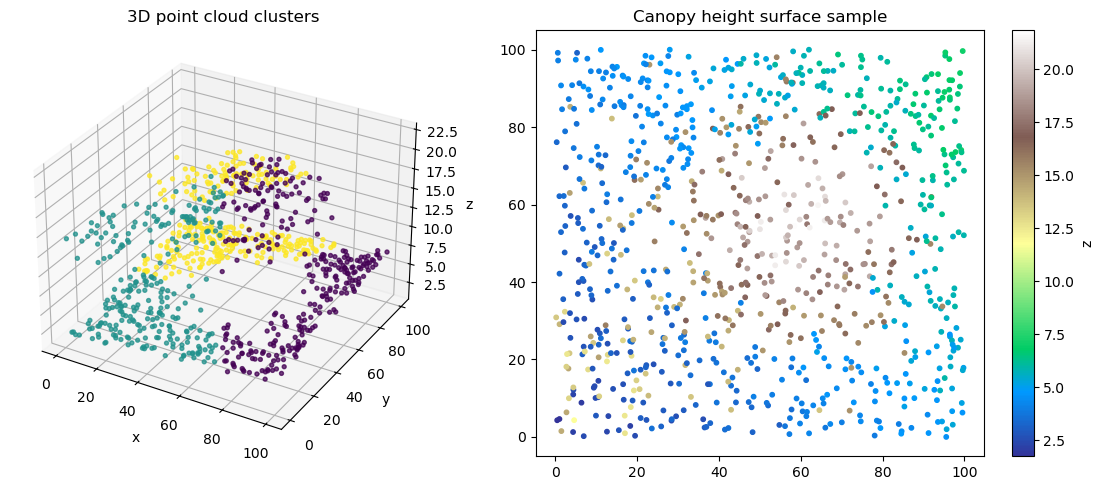

In [3]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.scatter(points.x, points.y, points.z, c=points.cluster, cmap='viridis', s=8, alpha=0.75)
ax.set_title('3D point cloud clusters')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax2 = fig.add_subplot(1, 2, 2)
sc = ax2.scatter(points.x, points.y, c=points.z, cmap='terrain', s=10)
ax2.set_title('Canopy height surface sample')
fig.colorbar(sc, ax=ax2, label='z')
fig.tight_layout()
fig.savefig(OUT / 'pointcloud_clusters.png', dpi=160)
plt.show()


In [4]:
summary = points.groupby('cluster').agg(mean_z=('z', 'mean'), max_z=('z', 'max'), points=('z', 'size')).round(2)
display(summary)


,mean_z,max_z,points
cluster,,,
0,9.98,21.70,319
1,7.61,19.26,281
2,8.48,21.85,300
